In [111]:
from sklearn.datasets import load_digits
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA



In [112]:

digits = load_digits()

In [113]:
print(digits.data.shape) 

(1797, 64)


In [114]:
print(digits.images[0])
print("Label:", digits.target[0])

[[ 0.  0.  5. 13.  9.  1.  0.  0.]
 [ 0.  0. 13. 15. 10. 15.  5.  0.]
 [ 0.  3. 15.  2.  0. 11.  8.  0.]
 [ 0.  4. 12.  0.  0.  8.  8.  0.]
 [ 0.  5.  8.  0.  0.  9.  8.  0.]
 [ 0.  4. 11.  0.  1. 12.  7.  0.]
 [ 0.  2. 14.  5. 10. 12.  0.  0.]
 [ 0.  0.  6. 13. 10.  0.  0.  0.]]
Label: 0


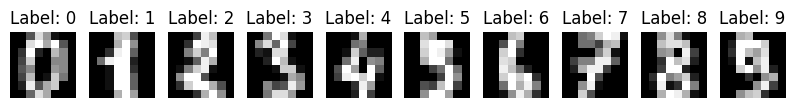

In [115]:
fig, axes = plt.subplots(1, 10, figsize=(10, 3))
for i in range(10):
    axes[i].imshow(digits.images[i], cmap='gray')
    axes[i].set_title(f"Label: {digits.target[i]}")
    axes[i].axis('off')

plt.show()

In [116]:
digits.data[0]

array([ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.,  0.,  0., 13., 15., 10.,
       15.,  5.,  0.,  0.,  3., 15.,  2.,  0., 11.,  8.,  0.,  0.,  4.,
       12.,  0.,  0.,  8.,  8.,  0.,  0.,  5.,  8.,  0.,  0.,  9.,  8.,
        0.,  0.,  4., 11.,  0.,  1., 12.,  7.,  0.,  0.,  2., 14.,  5.,
       10., 12.,  0.,  0.,  0.,  0.,  6., 13., 10.,  0.,  0.,  0.])

In [ ]:
# from sklearn.decomposition import PCA
# from sklearn.datasets import load_digits

# # بارگیری داده‌ها
# digits = load_digits()

# # PCA برای حفظ 70٪ واریانس
# pca = PCA(n_components=0.7)
# reduced_data = pca.fit_transform(digits.data)




In [118]:
digits.data[0]

array([ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.,  0.,  0., 13., 15., 10.,
       15.,  5.,  0.,  0.,  3., 15.,  2.,  0., 11.,  8.,  0.,  0.,  4.,
       12.,  0.,  0.,  8.,  8.,  0.,  0.,  5.,  8.,  0.,  0.,  9.,  8.,
        0.,  0.,  4., 11.,  0.,  1., 12.,  7.,  0.,  0.,  2., 14.,  5.,
       10., 12.,  0.,  0.,  0.,  0.,  6., 13., 10.,  0.,  0.,  0.])

In [119]:
pca = PCA(n_components=0.7)
pca.fit(digits.data)
print(f"Number of components to retain 70% variance: {pca.n_components_}")


Number of components to retain 70% variance: 9


In [132]:
print(reduced_data[0])


[-1.25946645 21.27488348 -9.46305462 13.01418869 -7.12882278 -7.44065876
  3.25283716  2.55347036 -0.58184214]


In [121]:
digits.data[0]

array([ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.,  0.,  0., 13., 15., 10.,
       15.,  5.,  0.,  0.,  3., 15.,  2.,  0., 11.,  8.,  0.,  0.,  4.,
       12.,  0.,  0.,  8.,  8.,  0.,  0.,  5.,  8.,  0.,  0.,  9.,  8.,
        0.,  0.,  4., 11.,  0.,  1., 12.,  7.,  0.,  0.,  2., 14.,  5.,
       10., 12.,  0.,  0.,  0.,  0.,  6., 13., 10.,  0.,  0.,  0.])

In [135]:
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total variance captured:", sum(pca.explained_variance_ratio_))


Explained variance ratio: [0.14890594 0.13618771]
Total variance captured: 0.2850936482369597


In [145]:
digits = load_digits()
pca = PCA(n_components=2)
X_pca = pca.fit_transform(digits.data)

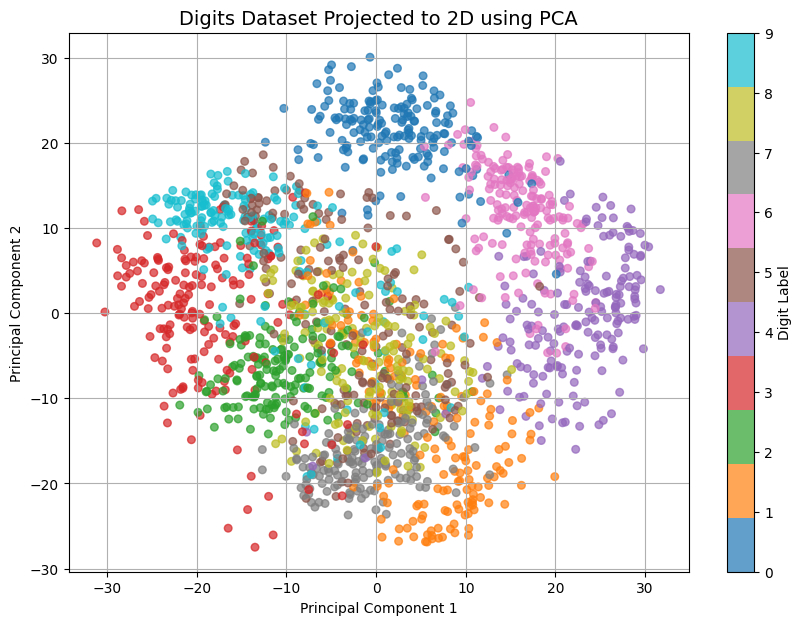

In [146]:
plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='tab10', s=30, alpha=0.7)

plt.title("Digits Dataset Projected to 2D using PCA", fontsize=14)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(scatter, label="Digit Label")
plt.grid(True)
plt.show()

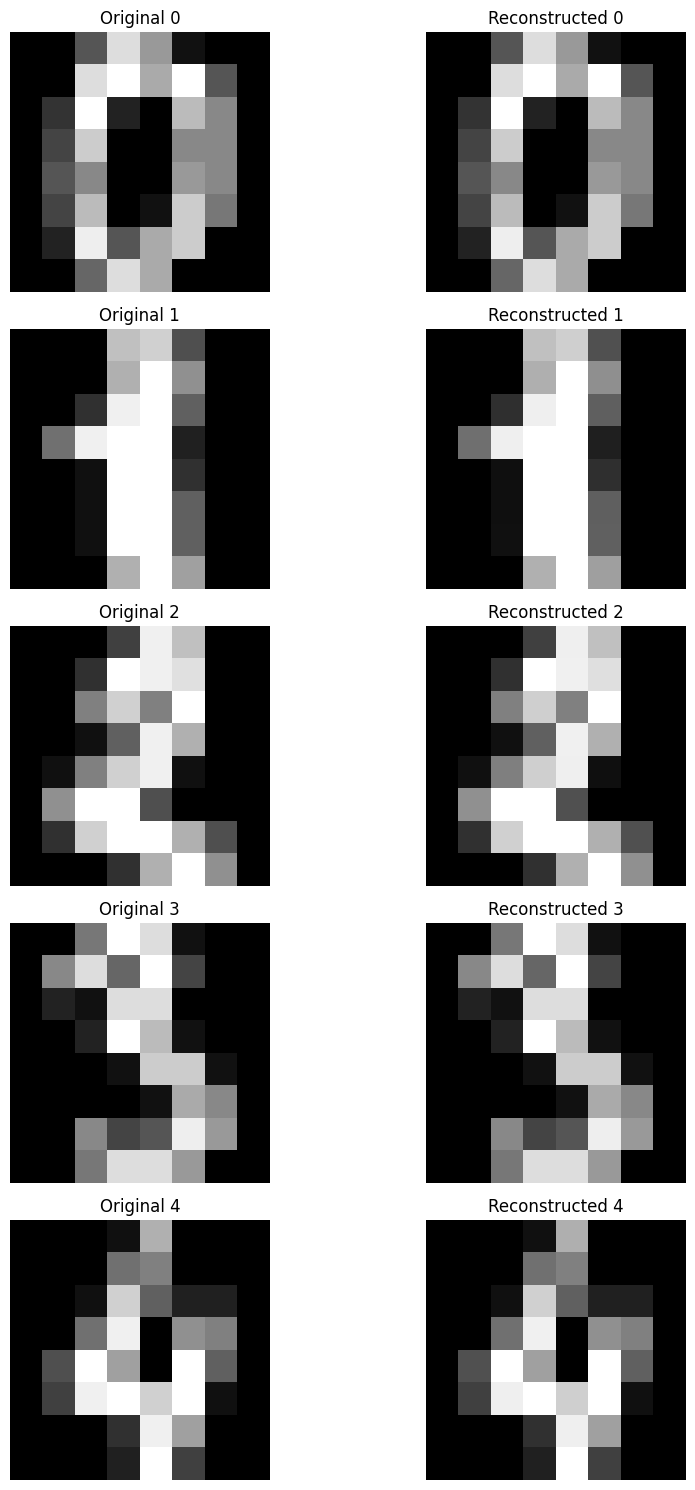

In [151]:
X_reconstructed = pca.inverse_transform(X_pca)

fig, axes = plt.subplots(5, 2, figsize=(10, 15))

for i in range(5):
    axes[i, 0].imshow(X[i].reshape(8, 8), cmap='gray')
    axes[i, 0].set_title(f"Original {digits.target[i]}")
    axes[i, 0].axis('off')
    
    axes[i, 1].imshow(X_reconstructed[i].reshape(8, 8), cmap='gray')
    axes[i, 1].set_title(f"Reconstructed {digits.target[i]}")
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

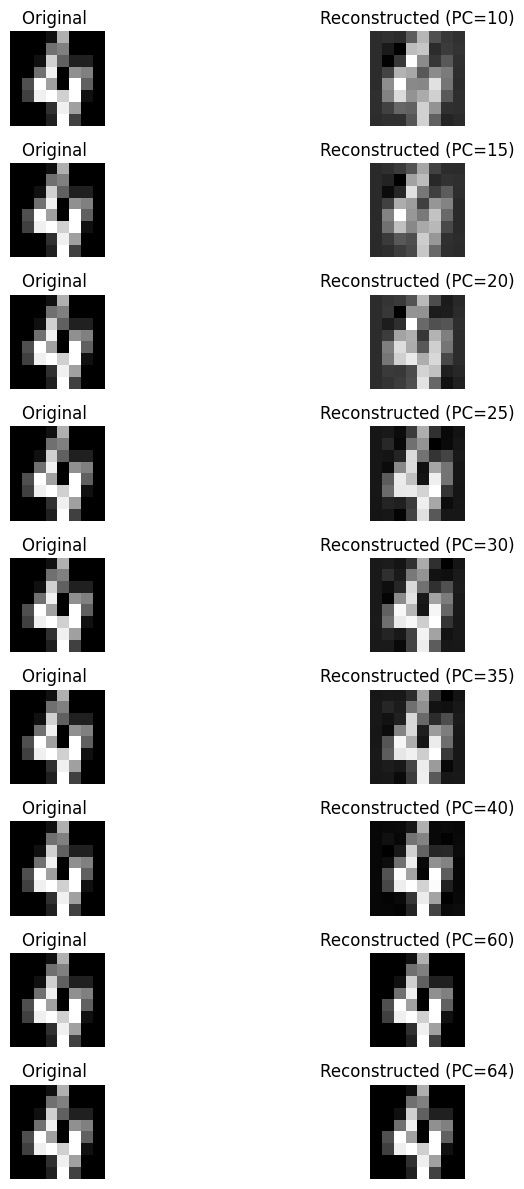

In [149]:
digits = load_digits()
X = digits.data

target_digit = 4
i = list(digits.target).index(target_digit)  

components_list = [10, 15, 20, 25, 30, 35, 40, 60,64]

fig, axes = plt.subplots(len(components_list), 2, figsize=(10, 12))

for idx, n_components in enumerate(components_list):
    pca = PCA(n_components=n_components)
    X_pca = pca.fit_transform(X)
    X_reconstructed = pca.inverse_transform(X_pca)

    axes[idx, 0].imshow(X[i].reshape(8, 8), cmap='gray')
    axes[idx, 0].axis('off')
    axes[idx, 0].set_title("Original ")

    axes[idx, 1].imshow(X_reconstructed[i].reshape(8, 8), cmap='gray')
    axes[idx, 1].axis('off')
    axes[idx, 1].set_title(f"Reconstructed (PC={n_components})")

plt.tight_layout()
plt.show()


In [155]:
digits = load_digits()
X = digits.data
components_list = [4,8,10, 15, 20, 25, 30, 35, 40, 60,64]
for j in components_list:
    pca = PCA(n_components=j)
    pca.fit(digits.data)
    print("Total variance captured:", sum(pca.explained_variance_ratio_))


Total variance captured: 0.48713938008591773
Total variance captured: 0.6739052814353248
Total variance captured: 0.7382261887898437
Total variance captured: 0.8353026145101371
Total variance captured: 0.8943001429111008
Total variance captured: 0.933027526542291
Total variance captured: 0.9590840999192093
Total variance captured: 0.9760840375560418
Total variance captured: 0.9882027336216872
Total variance captured: 0.9999996570942982
Total variance captured: 1.0000000000000002
